# CKG Reasoner v2 — A_Dengue_1000

Organized Colab workflow for the manuscript experiments. The diagnostic reasoner is fitted without outcome labels; ground truth is used only after partitioning for retrospective evaluation.

## 0. Reproducibility configuration

In [1]:
# Manuscript configuration
DISEASE = 'Dengue'
TARGET = 'Dengue_Outcome'
BASELINE_K = 3
RANDOM_STATE = 42
K_RANGE = range(2, 11)
CLUSTER_VARIABLES = ["P_evidence", "r", "c", "Confidence_Score"]
BOOTSTRAP_N = 1000
WITHHOLD_FRACTIONS = [0.10, 0.25, 0.50]
SEEDS = list(range(20))

print("Disease:", DISEASE)
print("Target:", TARGET)
print("Baseline K:", BASELINE_K)
print("Baseline clustering variables:", CLUSTER_VARIABLES)

Disease: Dengue
Target: Dengue_Outcome
Baseline K: 3
Baseline clustering variables: ['P_evidence', 'r', 'c', 'Confidence_Score']


## 1. Colab / package setup

In [2]:
from google.colab import drive
drive.mount("/content/drive", force_remount=False)


Mounted at /content/drive


In [3]:
import sys
import os
import importlib

# ============================================================
# CKG REASONER v1.0.0 — COLAB SOURCE SETUP
# ============================================================

PACKAGE_PATH = "/content/drive/MyDrive/CKG/ckg_reasoner_package_v2"
SRC_PATH = os.path.join(PACKAGE_PATH, "src")
CKG_PATH = os.path.join(SRC_PATH, "ckg_reasoner")

print("=== CKG REASONER v1.0.0 SETUP ===")
print("PACKAGE_PATH:", PACKAGE_PATH)
print("PACKAGE_PATH exists:", os.path.isdir(PACKAGE_PATH))
print("SRC_PATH:", SRC_PATH)
print("SRC_PATH exists:", os.path.isdir(SRC_PATH))
print("ckg_reasoner path:", CKG_PATH)
print("ckg_reasoner exists:", os.path.isdir(CKG_PATH))

# ------------------------------------------------------------
# 1. Validate required package structure
# ------------------------------------------------------------

if not os.path.isdir(PACKAGE_PATH):
    raise FileNotFoundError(
        f"Package directory not found:\n{PACKAGE_PATH}"
    )

if not os.path.isdir(SRC_PATH):
    raise FileNotFoundError(
        f"src directory not found:\n{SRC_PATH}"
    )

if not os.path.isdir(CKG_PATH):
    raise FileNotFoundError(
        f"ckg_reasoner package directory not found:\n{CKG_PATH}"
    )

required_files = [
    "__init__.py",
    "model.py",
    "reasoning.py",
    "knowledge.py",
]

missing_files = [
    filename
    for filename in required_files
    if not os.path.isfile(os.path.join(CKG_PATH, filename))
]

if missing_files:
    raise FileNotFoundError(
        "Required CKG package files are missing: "
        + ", ".join(missing_files)
    )

print("\nRequired package files: OK")


# ------------------------------------------------------------
# 2. Remove old CKG package paths from sys.path
# ------------------------------------------------------------

old_paths = [
    p for p in sys.path
    if "ckg_reasoner_package" in str(p)
]

if old_paths:
    print("\nRemoving old CKG paths:")
    for p in old_paths:
        print("  ", p)

sys.path = [
    p for p in sys.path
    if "ckg_reasoner_package" not in str(p)
]


# ------------------------------------------------------------
# 3. Put v1.0.0 src at highest priority
# ------------------------------------------------------------

sys.path.insert(0, SRC_PATH)

print("\nActive CKG source:")
print(sys.path[0])


# ------------------------------------------------------------
# 4. Remove stale imported CKG modules
# ------------------------------------------------------------

removed_modules = []

for name in list(sys.modules):
    if name == "ckg_reasoner" or name.startswith("ckg_reasoner."):
        removed_modules.append(name)
        del sys.modules[name]

if removed_modules:
    print("\nRemoved cached CKG modules:")
    for name in removed_modules:
        print("  ", name)

importlib.invalidate_caches()


# ------------------------------------------------------------
# 5. Import CKG Reasoner
# ------------------------------------------------------------

import ckg_reasoner
from ckg_reasoner import CKGModel


# ------------------------------------------------------------
# 6. Verify that the correct package was imported
# ------------------------------------------------------------

print("\n=== IMPORT CHECK ===")

print("Imported from:")
print(ckg_reasoner.__file__)

print("\nPackage path:")
print(list(ckg_reasoner.__path__))

print(
    "\nVersion:",
    getattr(ckg_reasoner, "__version__", "NO VERSION")
)

print(
    "CKGModel available:",
    hasattr(ckg_reasoner, "CKGModel")
)

print("CKGModel:")
print(CKGModel)


# ------------------------------------------------------------
# 7. Safety check — reject accidental old package imports
# ------------------------------------------------------------

imported_file = os.path.abspath(ckg_reasoner.__file__)
expected_root = os.path.abspath(SRC_PATH)

if not imported_file.startswith(expected_root):
    raise RuntimeError(
        "\nWRONG CKG PACKAGE IMPORTED!\n"
        f"Expected package under:\n{expected_root}\n\n"
        f"But imported:\n{imported_file}"
    )

print("\nSource-path verification: PASSED")


# ------------------------------------------------------------
# 8. Check important v1.0.0 modules
# ------------------------------------------------------------

important_modules = [
    "condition_logic.py",
    "units.py",
    "function_policy.py",
    "functions.py",
    "clinical_transformer.py",
    "mapping.py",
    "retrieval.py",
    "reporting.py",
]

print("\n=== MODULE CHECK ===")

for filename in important_modules:
    path = os.path.join(CKG_PATH, filename)

    print(
        f"{filename:<28}",
        "OK" if os.path.isfile(path) else "MISSING"
    )


# ------------------------------------------------------------
# 9. Check bundled data / knowledge files
# ------------------------------------------------------------

DATA_PATH = os.path.join(CKG_PATH, "data")

print("\n=== DATA CHECK ===")
print("Data directory:", DATA_PATH)
print("Data directory exists:", os.path.isdir(DATA_PATH))

if os.path.isdir(DATA_PATH):

    yaml_files = []

    for root, dirs, files in os.walk(DATA_PATH):
        for filename in files:
            if filename.lower().endswith((".yaml", ".yml")):
                yaml_files.append(
                    os.path.join(root, filename)
                )

    print("YAML files found:", len(yaml_files))

    for path in sorted(yaml_files):
        print(
            "  ",
            os.path.relpath(path, CKG_PATH)
        )


# ------------------------------------------------------------
# 10. Final status
# ------------------------------------------------------------

print("\n======================================")
print("CKG REASONER SETUP COMPLETED")
print("======================================")
print("Source :", SRC_PATH)
print(
    "Version:",
    getattr(ckg_reasoner, "__version__", "NO VERSION")
)
print("CKGModel: READY")
print("======================================")

=== CKG REASONER v1.0.0 SETUP ===
PACKAGE_PATH: /content/drive/MyDrive/CKG/ckg_reasoner_package_v2
PACKAGE_PATH exists: True
SRC_PATH: /content/drive/MyDrive/CKG/ckg_reasoner_package_v2/src
SRC_PATH exists: True
ckg_reasoner path: /content/drive/MyDrive/CKG/ckg_reasoner_package_v2/src/ckg_reasoner
ckg_reasoner exists: True

Required package files: OK

Active CKG source:
/content/drive/MyDrive/CKG/ckg_reasoner_package_v2/src

=== IMPORT CHECK ===
Imported from:
/content/drive/MyDrive/CKG/ckg_reasoner_package_v2/src/ckg_reasoner/__init__.py

Package path:
['/content/drive/MyDrive/CKG/ckg_reasoner_package_v2/src/ckg_reasoner']

Version: 2
CKGModel available: True
CKGModel:
<class 'ckg_reasoner.model.CKGModel'>

Source-path verification: PASSED

=== MODULE CHECK ===
condition_logic.py           OK
units.py                     OK
function_policy.py           OK
functions.py                 OK
clinical_transformer.py      OK
mapping.py                   OK
retrieval.py                 OK
rep

In [4]:
import sys
import os
import importlib

PACKAGE_PATH = "/content/drive/MyDrive/CKG/ckg_reasoner_package_v2"
SRC_PATH = os.path.join(PACKAGE_PATH, "src")

# Remove old CKG paths
sys.path = [
    p for p in sys.path
    if "ckg_reasoner_package" not in str(p)
]

# Force v0.9.6 to the front
sys.path.insert(0, SRC_PATH)

# Remove any stale cached ckg_reasoner modules
for name in list(sys.modules):
    if name == "ckg_reasoner" or name.startswith("ckg_reasoner."):
        del sys.modules[name]

importlib.invalidate_caches()

# Diagnostic
print("Using source:", SRC_PATH)
print("Exists:", os.path.isdir(SRC_PATH))
print("Package files:")
print(os.listdir(os.path.join(SRC_PATH, "ckg_reasoner"))[:20])

import ckg_reasoner

print("\nImported from:", ckg_reasoner.__file__)
print("Package path:", list(ckg_reasoner.__path__))
print("Version:", getattr(ckg_reasoner, "__version__", "NO VERSION"))
print("CKGModel available:", hasattr(ckg_reasoner, "CKGModel"))

Using source: /content/drive/MyDrive/CKG/ckg_reasoner_package_v2/src
Exists: True
Package files:
['graphview.py', 'retrieval.py', 'hard_assignment.py', 'visualization.py', 'clinical_transformer.py', 'function_policy.py', 'units.py', 'condition_logic.py', 'knowledge.py', 'evaluation.py', 'mapping.py', 'config.py', 'legacy_activation.py', 'functions.py', 'uncertainty.py', 'reporting.py', 'explanation.py', 'confidence.py', 'reasoning.py', 'gaussian.py']

Imported from: /content/drive/MyDrive/CKG/ckg_reasoner_package_v2/src/ckg_reasoner/__init__.py
Package path: ['/content/drive/MyDrive/CKG/ckg_reasoner_package_v2/src/ckg_reasoner']
Version: 2
CKGModel available: True


In [5]:
from ckg_reasoner import CKGModel, __version__

model = CKGModel()

print("Version:", __version__)
print(model.kb.audit())

Version: 2
{'knowledge_base_path': '/content/drive/MyDrive/CKG/ckg_reasoner_package_v2/src/ckg_reasoner/data/diseases', 'disease_graph_count': 3, 'diseases': ['Dengue Fever', 'Influenza', 'Malaria'], 'yaml_file_count': 12}


## 2. Load cohort

In [6]:
import pandas as pd

DATA_PATH = "/content/drive/MyDrive/CKG/KG2_Selected_4_Datasets/5_kaggle_bangladesh_Dengue.csv"

df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
display(df.head())

print("\nColumns:")
for col in df.columns:
    print(col)

Shape: (1000, 24)


,id,Gender,Age,NS1,IGG,IGM,Area,AreaType,HouseType,District,...,ART_severity,HDH,ROP,MYA,RSH,SOR,RHI,COU,MAL,Dengue_Outcome
0,1,Female,45,0,0,0,Mirpur,Undeveloped,Building,Dhaka,...,Severe,0,0,1,0,0,0,0,0,0
1,2,Male,17,0,0,1,Chawkbazar,Developed,Building,Dhaka,...,NaN,1,0,0,0,0,0,0,0,0
2,3,Female,29,0,0,0,Paltan,Undeveloped,Other,Dhaka,...,NaN,0,0,0,0,0,0,0,0,0
3,4,Female,63,1,1,0,Motijheel,Developed,Other,Dhaka,...,Moderate,0,0,1,0,0,0,0,0,1
4,5,Male,22,0,0,0,Gendaria,Undeveloped,Building,Dhaka,...,NaN,0,0,0,0,0,0,0,0,0



Columns:
id
Gender
Age
NS1
IGG
IGM
Area
AreaType
HouseType
District
FEV_dura_dy
FEV_temperature_c
MTP_platelet_count:
LEU_wbc
ART_severity
HDH
ROP
MYA
RSH
SOR
RHI
COU
MAL
Dengue_Outcome


## 3. Map patient variables and run frozen KG reasoning

In [7]:
model.hmap(df, interactive=False)

print("\nDetected schema:")
print(model.detected_schema_)

print("\nDetected target:")
print(model.target_column_)

print("\nHeader mapping report:")
display(model.hmap_report())

Detected dataset schema: C1_Bangladesh_Dengue_1000 (confidence=1.00)
Successful matches found: 16 dataset headings mapped to ontology headings.
    dataset_heading   ontology_heading
                NS1                NS1
                IGG                IGG
                IGM                IGM
        FEV_dura_dy        FEV_dura_dy
  FEV_temperature_c  FEV_temperature_c
MTP_platelet_count: MTP_platelet_count
            LEU_wbc            LEU_wbc
       ART_severity       ART_severity
                HDH                HDH
                ROP                ROP
                MYA                MYA
                RSH                RSH
                SOR                SOR
                RHI                RHI
                COU                COU
                MAL                MAL
Ignored metadata/target headings: ['id', 'Gender', 'Age', 'Area', 'AreaType', 'HouseType', 'District', 'Dengue_Outcome']

Detected schema:
C1_Bangladesh_Dengue_1000

Detected target:
Dengue_Out

,dataset_heading,ontology_heading,status,confidence,source_unit,canonical_unit,unit_status
0,id,None,ignored,1.0,None,None,not_mapped
1,Gender,None,ignored,1.0,None,None,not_mapped
2,Age,None,ignored,1.0,None,None,not_mapped
3,NS1,NS1,alias_exact,1.0,None,None,pass_through
4,IGG,IGG,alias_exact,1.0,None,None,pass_through
5,IGM,IGM,alias_exact,1.0,None,None,pass_through
6,Area,None,ignored,1.0,None,None,not_mapped
7,AreaType,None,ignored,1.0,None,None,not_mapped
8,HouseType,None,ignored,1.0,None,None,not_mapped
9,District,None,ignored,1.0,None,None,not_mapped


In [8]:
model.graphfit(strategy="exhaustive")



Graph fitting completed for 1000 record(s); strategy='exhaustive'; knowledge base=3 disease graph(s).
Auto K-means completed on S0=[P_evidence, r, c, Confidence_Score] (optimal K=6; target ordering=Dengue Fever).


CKGModel(state='fitted', diseases=['Dengue Fever', 'Influenza', 'Malaria'], rows=1000)

## 4. Single-record reasoning sanity check

In [9]:
model.evidence("Dengue", row=0)
model.Continuous_reasoning("Dengue", row=0)
model.Deterministic_reasoning("Dengue", row=0)
model.Uncertainty("Dengue", row=0)
model.explain("Dengue", row=0)

{'Dengue Fever': {'patient_id': 0,
  'disease': 'Dengue Fever',
  'evidence_facts': [{'feature': 'LEU_laboratory',
    'name': 'Leukopenia',
    'observed': True,
    'observations': [{'component': 'wbc', 'value': 5806}],
    'similarity': 0.0,
    'clinical_importance': 1.0,
    'specificity': 0.85,
    'support': 0.8,
    'contradiction': 0.8,
    'positive_contribution': 0.0027559548258750052,
    'negative_contribution': 0.7911732690881602},
   {'feature': 'MTP_laboratory',
    'name': 'Mild Thrombocytopenia',
    'observed': True,
    'observations': [{'component': 'platelet_count', 'value': 278586}],
    'similarity': 0.0,
    'clinical_importance': 1.0,
    'specificity': 0.85,
    'support': 0.8,
    'contradiction': 0.8,
    'positive_contribution': 0.0027559548258750052,
    'negative_contribution': 0.7911732690881602},
   {'feature': 'NS1_laboratory',
    'name': 'NS1',
    'observed': True,
    'observations': [{'component': 'default', 'value': 0}],
    'similarity': 0.0,
 

## 5. Label-free clustering diagnostics

Elbow-recommended cluster number: 2
Silhouette-recommended cluster number: 2
Combined best cluster number: 2


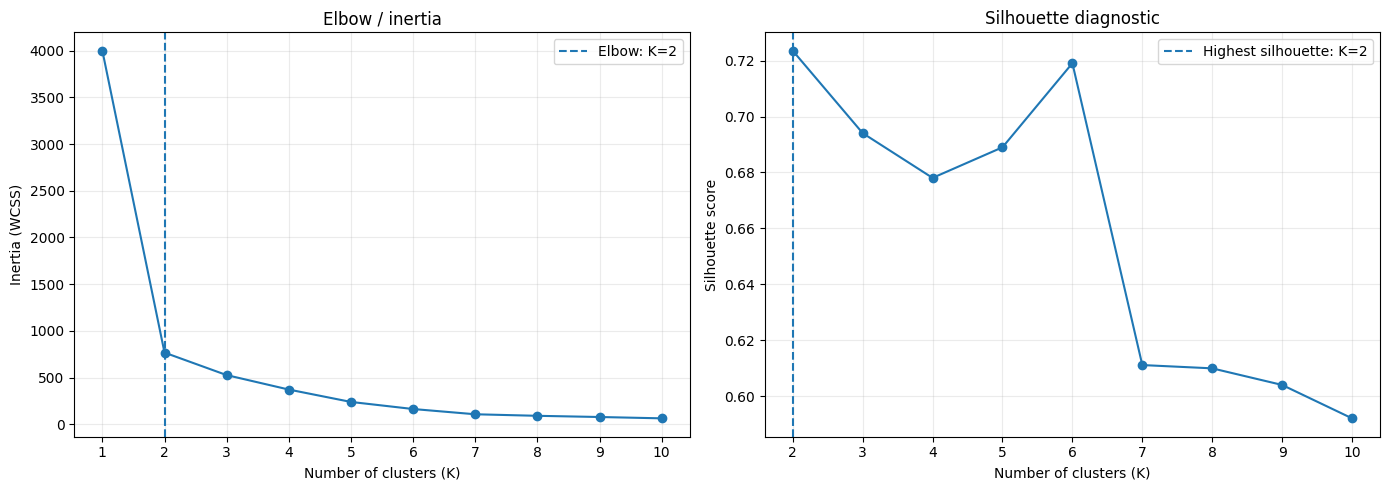

kmeans diagnostics complete. Advisory recommended n=2; choose n manually for the final fit.


,n,k,inertia,silhouette,elbow_strength,silhouette_strength,combined_score
0,1,1,4000.000000,NaN,0.000000,NaN,NaN
1,2,2,766.720645,0.723545,1.000000,1.000000,1.000000
2,3,3,525.785780,0.694081,0.929700,0.775866,0.852783
3,4,4,370.921746,0.678067,0.828613,0.654043,0.741328
4,5,5,238.362660,0.689006,0.719549,0.737256,0.728403
5,6,6,162.469480,0.719079,0.590217,0.966030,0.778123
6,7,7,106.287560,0.611143,0.453834,0.144940,0.299387
7,8,8,89.765019,0.609966,0.303266,0.135987,0.219627
8,9,9,77.024193,0.604031,0.151345,0.090833,0.121089
9,10,10,62.673437,0.592090,0.000000,0.000000,0.000000


Elbow k: 2
Silhouette k: 2
Combined best k: 2


In [10]:
# Baseline K-means diagnostics on all four post-KG coordinates.
kdiag = model.diagnostics(
    "kmeans", positive_disease=DISEASE, min_clusters=2, max_clusters=10,
    variables=None, show=True, print_recommendations=True
)
display(kdiag)
print("Elbow k:", kdiag.attrs.get("elbow_recommended_n"))
print("Silhouette k:", kdiag.attrs.get("silhouette_recommended_n"))
print("Combined best k:", kdiag.attrs.get("best_k", kdiag.attrs.get("recommended_n")))

## 6. Pre-specified baseline partition and retrospective evaluation

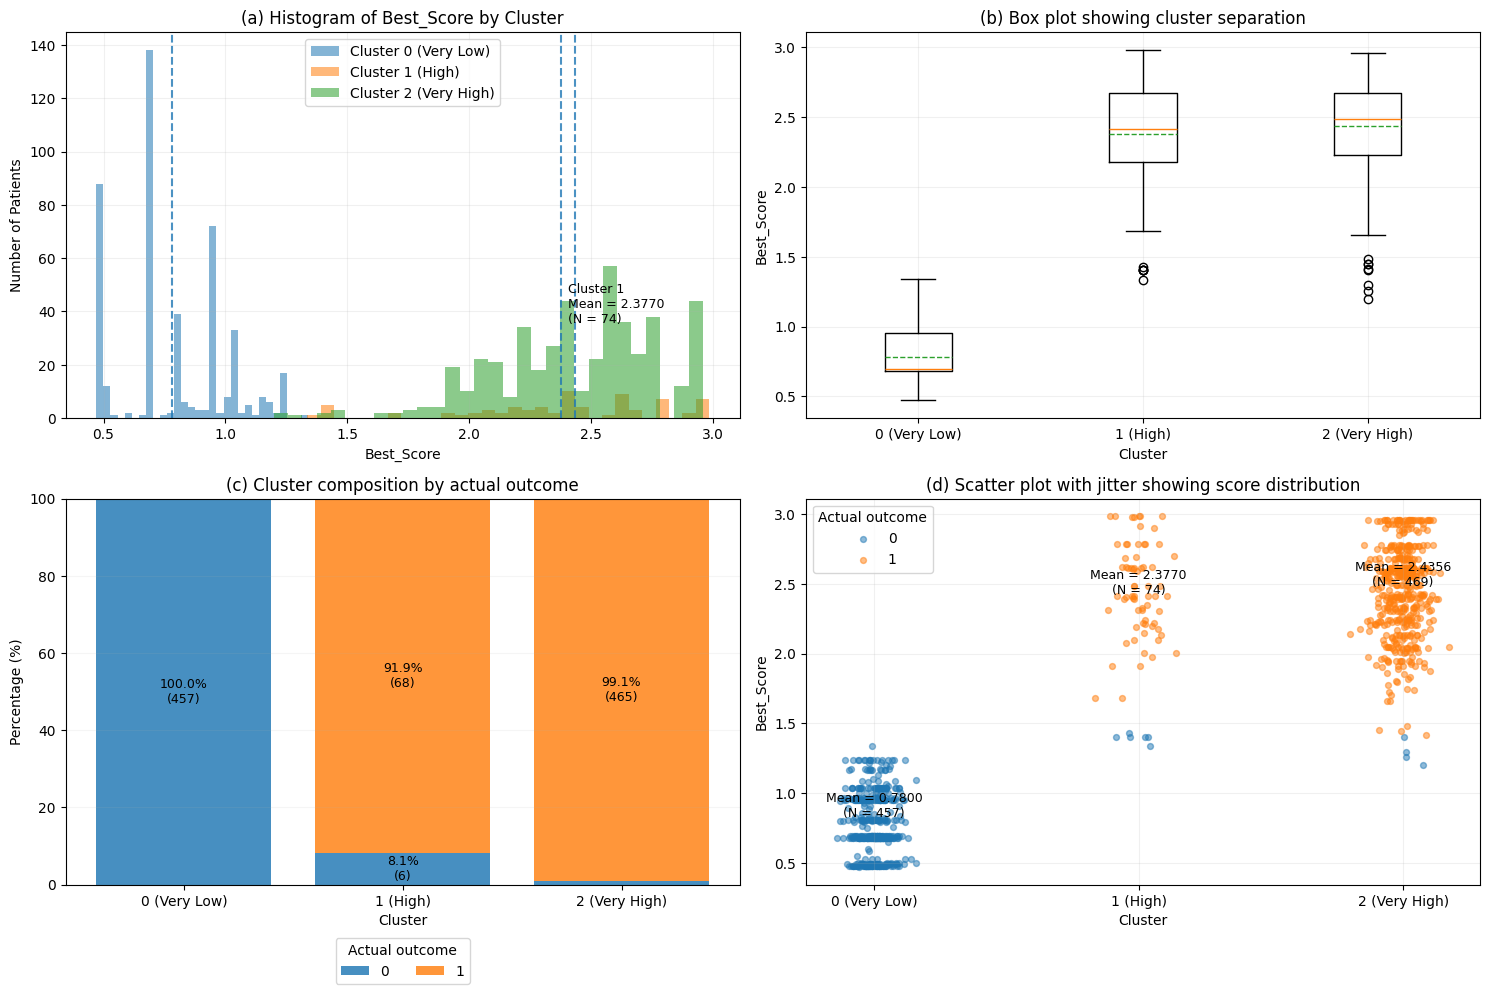

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


ALL-RECORD EVALUATION
{'n': 1000, 'accuracy': 0.922, 'balanced_accuracy': np.float64(0.9255034932164508), 'precision_macro': 0.6638237384506042, 'recall_macro': 0.6170023288109672, 'f1_macro': 0.6391070672507798, 'f1_weighted': 0.9566464862482826, 'mcc': np.float64(0.8641762618672785), 'cohen_kappa': np.float64(0.8546414115437082), 'ground_truth_counts': {'positive': 533, 'negative': 467}, 'prediction_counts': {'positive': 469, 'negative': 457, 'indeterminate': 74}, 'labels': ['indeterminate', 'negative', 'positive'], 'confusion_matrix': array([[  0,   0,   0],
       [  6, 457,   4],
       [ 68,   0, 465]]), 'f1_positive': 0.9281437125748503, 'f1': 0.9281437125748503, 'n_total': 1000, 'n_indeterminate': 74, 'coverage': 0.926, 'abstention_rate': 0.074, 'positive_disease': 'Dengue Fever', 'tag_method': 'kmeans', 'evaluation_mode': 'all records; indeterminate retained as a third predicted label'}

DECIDED/SUBSET EVALUATION
{'n': 926, 'accuracy': 0.9956803455723542, 'balanced_accuracy': 

In [11]:
from ckg_reasoner import KMeansPartition

km = model.partition(
    KMeansPartition(n_clusters=BASELINE_K, min_clusters=2, max_clusters=10,
                    random_state=RANDOM_STATE, n_init=20, variables=None),
    DISEASE, show=False
)
km.visualize(y_true=model.df_[TARGET])

result_all = model.evaluate(y_true=TARGET, positive_disease=DISEASE, positive_label=1, method=km)
result_selective = model.evaluate_tag(y_true=TARGET, positive_disease=DISEASE, positive_label=1, method=km)
print("ALL-RECORD EVALUATION")
print(result_all)
print("\nDECIDED/SUBSET EVALUATION")
print(result_selective)

## 7. Manuscript component ablation — post-KG representation

These experiments change only the coordinates supplied to K-means. They do **not** refit the diagnostic reasoner. The first six rows correspond to the manuscript table; `No CS` is an additional exploratory check.

In [12]:
import pandas as pd
import numpy as np
from sklearn.metrics import adjusted_rand_score

ABLATIONS = {
    "Full": None,  # variables=None => all four eligible coordinates
    "No P_evidence": ["r", "c", "Confidence_Score"],
    "No r": ["P_evidence", "c", "Confidence_Score"],
    "No c": ["P_evidence", "r", "Confidence_Score"],
    "P_evidence only": ["P_evidence"],
    "Profile only (r,c)": ["r", "c"],
    "No CS [exploratory]": ["P_evidence", "r", "c"],
}

def metric_value(d, *names):
    for n in names:
        if n in d: return d[n]
    return np.nan

baseline_tags = km.predictions_.astype(str)
rows=[]
partition_objects={}
for name, variables in ABLATIONS.items():
    part=model.partition(KMeansPartition(n_clusters=BASELINE_K, min_clusters=2, max_clusters=10,
                         random_state=RANDOM_STATE, n_init=20, variables=variables), DISEASE, show=False)
    partition_objects[name]=part
    allm=model.evaluate(y_true=TARGET, positive_disease=DISEASE, positive_label=1, method=part)
    selm=model.evaluate_tag(y_true=TARGET, positive_disease=DISEASE, positive_label=1, method=part)
    rows.append({
        "ablation":name, "variables":"ALL 4" if variables is None else ", ".join(variables),
        "ARI_vs_full":adjusted_rand_score(baseline_tags,part.predictions_.astype(str)),
        "accuracy_all":metric_value(allm,"accuracy"),
        "balanced_accuracy_all":metric_value(allm,"balanced_accuracy"),
        "MCC_all":metric_value(allm,"mcc","matthews_corrcoef"),
        "F1_positive_all":metric_value(allm,"f1_positive","f1"),
        "F1_positive_decided":metric_value(selm,"f1_positive","f1"),
        "coverage":metric_value(selm,"coverage"),
        "n_indeterminate":metric_value(selm,"n_indeterminate"),
    })
component_ablation=pd.DataFrame(rows)
display(component_ablation)

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/usr/local/lib/python3.13/dist-packages/sklearn/metrics

,ablation,variables,ARI_vs_full,accuracy_all,balanced_accuracy_all,MCC_all,F1_positive_all,F1_positive_decided,coverage,n_indeterminate
0,Full,ALL 4,1.000000,0.922,0.925503,0.864176,0.928144,0.995717,0.926,74
1,No P_evidence,"r, c, Confidence_Score",0.938096,0.897,0.898737,0.823355,0.922619,0.989362,0.907,93
2,No r,"P_evidence, c, Confidence_Score",0.989292,0.530,0.558437,0.524655,0.225914,0.992701,0.531,469
3,No c,"P_evidence, r, Confidence_Score",0.981809,0.528,0.556295,0.522656,0.225914,0.992701,0.529,471
4,P_evidence only,P_evidence,0.697084,0.821,0.831950,0.742628,0.799550,1.000000,0.821,179
5,"Profile only (r,c)","r, c",0.695907,0.633,0.607199,0.559784,0.991612,0.992537,0.641,359
6,No CS [exploratory],"P_evidence, r, c",0.641474,0.813,0.800316,0.726254,0.996234,1.000000,0.813,187


## 8. K sensitivity and 20-seed stability

In [13]:
# K sensitivity (K=2,...,10) using all four coordinates.
k_rows=[]
for kval in K_RANGE:
    p=model.partition(KMeansPartition(n_clusters=kval,min_clusters=2,max_clusters=10,random_state=RANDOM_STATE,n_init=20,variables=None),DISEASE,show=False)
    a=model.evaluate(y_true=TARGET,positive_disease=DISEASE,positive_label=1,method=p)
    s=model.evaluate_tag(y_true=TARGET,positive_disease=DISEASE,positive_label=1,method=p)
    k_rows.append({"k":kval,"accuracy":metric_value(a,"accuracy"),"balanced_accuracy":metric_value(a,"balanced_accuracy"),
                   "f1_positive":metric_value(s,"f1_positive","f1"),"coverage":metric_value(s,"coverage")})
k_sensitivity=pd.DataFrame(k_rows)
display(k_sensitivity)

# Seed stability against seed-42 baseline.
seed_rows=[]
for seed in SEEDS:
    p=model.partition(KMeansPartition(n_clusters=BASELINE_K,min_clusters=2,max_clusters=10,random_state=seed,n_init=20,variables=None),DISEASE,show=False)
    s=model.evaluate_tag(y_true=TARGET,positive_disease=DISEASE,positive_label=1,method=p)
    seed_rows.append({"seed":seed,"ARI_vs_seed42":adjusted_rand_score(baseline_tags,p.predictions_.astype(str)),
                      "f1_positive":metric_value(s,"f1_positive","f1"),"coverage":metric_value(s,"coverage")})
seed_stability=pd.DataFrame(seed_rows)
display(seed_stability)

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/usr/local/lib/python3.13/dist-packages/sklearn/metrics

,k,accuracy,balanced_accuracy,f1_positive,coverage
0,2,0.996,0.995717,0.996262,1.000
1,3,0.922,0.925503,0.995717,0.926
2,4,0.882,0.882677,1.000000,0.882
3,5,0.156,0.158008,0.992701,0.157
4,6,0.156,0.158008,1.000000,0.156
5,7,0.326,0.317483,1.000000,0.326
6,8,0.326,0.317483,1.000000,0.326
7,9,0.300,0.293093,1.000000,0.300
8,10,0.300,0.293093,1.000000,0.300


,seed,ARI_vs_seed42,f1_positive,coverage
0,0,1.0,0.995717,0.926
1,1,1.0,0.995717,0.926
2,2,1.0,0.995717,0.926
3,3,1.0,0.995717,0.926
4,4,1.0,0.995717,0.926
5,5,1.0,0.995717,0.926
6,6,1.0,0.995717,0.926
7,7,1.0,0.995717,0.926
8,8,1.0,0.995717,0.926
9,9,1.0,0.995717,0.926


## 9. Bootstrap uncertainty (1,000 nonparametric resamples)

This bootstraps the fixed baseline predictions; it does not refit K-means and therefore quantifies sampling uncertainty of the reported retrospective metrics.

In [14]:
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, matthews_corrcoef

truth=(model.df_[TARGET].astype(str).str.strip().str.lower().isin(["1","1.0","true","yes","positive","pos"])).astype(int).to_numpy()
pred_tag=km.predictions_.astype(str).to_numpy()
rng=np.random.default_rng(RANDOM_STATE)
boot=[]
for b in range(BOOTSTRAP_N):
    ix=rng.integers(0,len(truth),len(truth))
    yt=truth[ix]; pt=pred_tag[ix]
    yp=(pt=="positive").astype(int)
    decided=(pt!="indeterminate")
    row={"accuracy_all":accuracy_score(yt,yp),"coverage":decided.mean()}
    if len(np.unique(yt))>1:
        row["balanced_accuracy_all"]=balanced_accuracy_score(yt,yp)
        row["mcc_all"]=matthews_corrcoef(yt,yp)
    else:
        row["balanced_accuracy_all"]=np.nan; row["mcc_all"]=np.nan
    if decided.any(): row["f1_positive_decided"]=f1_score(yt[decided],yp[decided],zero_division=0)
    else: row["f1_positive_decided"]=np.nan
    boot.append(row)
bootstrap_df=pd.DataFrame(boot)
bootstrap_ci=bootstrap_df.quantile([0.025,0.5,0.975]).T.rename(columns={0.025:"CI_2.5%",0.5:"median",0.975:"CI_97.5%"})
display(bootstrap_ci)

,CI_2.5%,median,CI_97.5%
accuracy_all,0.912000,0.928000,0.944000
coverage,0.910000,0.926000,0.942000
balanced_accuracy_all,0.917177,0.931914,0.946019
mcc_all,0.834551,0.863475,0.892103
f1_positive_decided,0.990455,0.995736,0.998966


## 10. Reasoner-level ablations: contradiction and clinical importance

These rerun `graphfit()` after changing the encoded disease knowledge. They are intentionally separate from coordinate ablation.

In [15]:
from copy import deepcopy

def fresh_model_from_df(df_variant, knowledge_ablation=None):
    m=CKGModel()
    if knowledge_ablation is not None:
        for disease_key, refs in m.kb.reference_vectors.items():
            for _, ref in refs.items():
                if knowledge_ablation=="no_contradiction": ref["contradiction"]="None"
                elif knowledge_ablation=="importance_unity": ref["importance"]="Critical"  # encoded value 1.0
    m.hmap(df_variant.copy(),interactive=False)
    m.graphfit(strategy="exhaustive")
    return m

def run_model_partition(m, k=BASELINE_K):
    p=m.partition(KMeansPartition(n_clusters=k,min_clusters=2,max_clusters=10,random_state=RANDOM_STATE,n_init=20,variables=None),DISEASE,show=False)
    a=m.evaluate(y_true=TARGET,positive_disease=DISEASE,positive_label=1,method=p)
    s=m.evaluate_tag(y_true=TARGET,positive_disease=DISEASE,positive_label=1,method=p)
    return p,a,s

knowledge_rows=[]
for abl in ["no_contradiction","importance_unity"]:
    m2=fresh_model_from_df(df,abl)
    p,a,s=run_model_partition(m2)
    knowledge_rows.append({"ablation":abl,"ARI_vs_full":adjusted_rand_score(baseline_tags,p.predictions_.astype(str)),
        "accuracy_all":metric_value(a,"accuracy"),"f1_positive_decided":metric_value(s,"f1_positive","f1"),"coverage":metric_value(s,"coverage")})
knowledge_ablation=pd.DataFrame(knowledge_rows)
display(knowledge_ablation)

Detected dataset schema: C1_Bangladesh_Dengue_1000 (confidence=1.00)
Successful matches found: 16 dataset headings mapped to ontology headings.
    dataset_heading   ontology_heading
                NS1                NS1
                IGG                IGG
                IGM                IGM
        FEV_dura_dy        FEV_dura_dy
  FEV_temperature_c  FEV_temperature_c
MTP_platelet_count: MTP_platelet_count
            LEU_wbc            LEU_wbc
       ART_severity       ART_severity
                HDH                HDH
                ROP                ROP
                MYA                MYA
                RSH                RSH
                SOR                SOR
                RHI                RHI
                COU                COU
                MAL                MAL
Ignored metadata/target headings: ['id', 'Gender', 'Age', 'Area', 'AreaType', 'HouseType', 'District', 'Dengue_Outcome']
Graph fitting completed for 1000 record(s); strategy='exhaustive'; knowl

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


Detected dataset schema: C1_Bangladesh_Dengue_1000 (confidence=1.00)
Successful matches found: 16 dataset headings mapped to ontology headings.
    dataset_heading   ontology_heading
                NS1                NS1
                IGG                IGG
                IGM                IGM
        FEV_dura_dy        FEV_dura_dy
  FEV_temperature_c  FEV_temperature_c
MTP_platelet_count: MTP_platelet_count
            LEU_wbc            LEU_wbc
       ART_severity       ART_severity
                HDH                HDH
                ROP                ROP
                MYA                MYA
                RSH                RSH
                SOR                SOR
                RHI                RHI
                COU                COU
                MAL                MAL
Ignored metadata/target headings: ['id', 'Gender', 'Age', 'Area', 'AreaType', 'HouseType', 'District', 'Dengue_Outcome']
Graph fitting completed for 1000 record(s); strategy='exhaustive'; knowl

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


,ablation,ARI_vs_full,accuracy_all,f1_positive_decided,coverage
0,no_contradiction,0.997840,0.923,0.995717,0.927
1,importance_unity,0.997839,0.921,0.995717,0.925


## 11. Evidence-gate parameter sensitivity

One parameter family is varied at a time around the frozen baseline (α=0.05, β=10, γ=0.85). This is a controlled runtime patch for sensitivity analysis only; it does **not** modify the installed package files.

In [16]:
import math, contextlib
import ckg_reasoner.functions as ckg_functions
import ckg_reasoner.reasoning as ckg_reasoning

@contextlib.contextmanager
def temporary_gate(alpha=0.05,beta=10.0,gamma=0.85):
    old_fun=ckg_functions.manuscript_evidence_contributions
    old_reason=ckg_reasoning.manuscript_evidence_contributions
    def contrib(*,information_gate,diagnostic_role,importance,support,contradiction):
        def fgate(x):
            x=float(np.clip(x,0,1)); return 1.0/(1.0+alpha*math.exp(-beta*(x-gamma)))
        ig=float(np.clip(information_gate,0,1))
        return (fgate(ig)*max(float(diagnostic_role),0.0)*float(importance)*max(float(support),0.0),
                fgate(1.0-ig)*abs(float(contradiction)))
    ckg_functions.manuscript_evidence_contributions=contrib
    ckg_reasoning.manuscript_evidence_contributions=contrib
    try: yield
    finally:
        ckg_functions.manuscript_evidence_contributions=old_fun
        ckg_reasoning.manuscript_evidence_contributions=old_reason

gate_settings=[("baseline",0.05,10,0.85)]
gate_settings += [(f"alpha={x}",x,10,0.85) for x in [0.025,0.10]]
gate_settings += [(f"beta={x}",0.05,x,0.85) for x in [5,20]]
gate_settings += [(f"gamma={x}",0.05,10,x) for x in [0.75,0.95]]
gate_rows=[]
for name,a,b,g in gate_settings:
    with temporary_gate(a,b,g):
        mg=fresh_model_from_df(df)
        p,am,sm=run_model_partition(mg)
    gate_rows.append({"setting":name,"alpha":a,"beta":b,"gamma":g,"ARI_vs_full":adjusted_rand_score(baseline_tags,p.predictions_.astype(str)),
                      "f1_positive_decided":metric_value(sm,"f1_positive","f1"),"coverage":metric_value(sm,"coverage")})
gate_sensitivity=pd.DataFrame(gate_rows)
display(gate_sensitivity)

Detected dataset schema: C1_Bangladesh_Dengue_1000 (confidence=1.00)
Successful matches found: 16 dataset headings mapped to ontology headings.
    dataset_heading   ontology_heading
                NS1                NS1
                IGG                IGG
                IGM                IGM
        FEV_dura_dy        FEV_dura_dy
  FEV_temperature_c  FEV_temperature_c
MTP_platelet_count: MTP_platelet_count
            LEU_wbc            LEU_wbc
       ART_severity       ART_severity
                HDH                HDH
                ROP                ROP
                MYA                MYA
                RSH                RSH
                SOR                SOR
                RHI                RHI
                COU                COU
                MAL                MAL
Ignored metadata/target headings: ['id', 'Gender', 'Age', 'Area', 'AreaType', 'HouseType', 'District', 'Dengue_Outcome']
Graph fitting completed for 1000 record(s); strategy='exhaustive'; knowl

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


Detected dataset schema: C1_Bangladesh_Dengue_1000 (confidence=1.00)
Successful matches found: 16 dataset headings mapped to ontology headings.
    dataset_heading   ontology_heading
                NS1                NS1
                IGG                IGG
                IGM                IGM
        FEV_dura_dy        FEV_dura_dy
  FEV_temperature_c  FEV_temperature_c
MTP_platelet_count: MTP_platelet_count
            LEU_wbc            LEU_wbc
       ART_severity       ART_severity
                HDH                HDH
                ROP                ROP
                MYA                MYA
                RSH                RSH
                SOR                SOR
                RHI                RHI
                COU                COU
                MAL                MAL
Ignored metadata/target headings: ['id', 'Gender', 'Age', 'Area', 'AreaType', 'HouseType', 'District', 'Dengue_Outcome']
Graph fitting completed for 1000 record(s); strategy='exhaustive'; knowl

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


Detected dataset schema: C1_Bangladesh_Dengue_1000 (confidence=1.00)
Successful matches found: 16 dataset headings mapped to ontology headings.
    dataset_heading   ontology_heading
                NS1                NS1
                IGG                IGG
                IGM                IGM
        FEV_dura_dy        FEV_dura_dy
  FEV_temperature_c  FEV_temperature_c
MTP_platelet_count: MTP_platelet_count
            LEU_wbc            LEU_wbc
       ART_severity       ART_severity
                HDH                HDH
                ROP                ROP
                MYA                MYA
                RSH                RSH
                SOR                SOR
                RHI                RHI
                COU                COU
                MAL                MAL
Ignored metadata/target headings: ['id', 'Gender', 'Age', 'Area', 'AreaType', 'HouseType', 'District', 'Dengue_Outcome']
Graph fitting completed for 1000 record(s); strategy='exhaustive'; knowl

...

Detected dataset schema: C1_Bangladesh_Dengue_1000 (confidence=1.00)
Successful matches found: 16 dataset headings mapped to ontology headings.
    dataset_heading   ontology_heading
                NS1                NS1
                IGG                IGG
                IGM                IGM
        FEV_dura_dy        FEV_dura_dy
  FEV_temperature_c  FEV_temperature_c
MTP_platelet_count: MTP_platelet_count
            LEU_wbc            LEU_wbc
       ART_severity       ART_severity
                HDH                HDH
                ROP                ROP
                MYA                MYA
                RSH                RSH
                SOR                SOR
                RHI                RHI
                COU                COU
                MAL                MAL
Ignored metadata/target headings: ['id', 'Gender', 'Age', 'Area', 'AreaType', 'HouseType', 'District', 'Dengue_Outcome']
Graph fitting completed for 1000 record(s); strategy='exhaustive'; knowl

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


Detected dataset schema: C1_Bangladesh_Dengue_1000 (confidence=1.00)
Successful matches found: 16 dataset headings mapped to ontology headings.
    dataset_heading   ontology_heading
                NS1                NS1
                IGG                IGG
                IGM                IGM
        FEV_dura_dy        FEV_dura_dy
  FEV_temperature_c  FEV_temperature_c
MTP_platelet_count: MTP_platelet_count
            LEU_wbc            LEU_wbc
       ART_severity       ART_severity
                HDH                HDH
                ROP                ROP
                MYA                MYA
                RSH                RSH
                SOR                SOR
                RHI                RHI
                COU                COU
                MAL                MAL
Ignored metadata/target headings: ['id', 'Gender', 'Age', 'Area', 'AreaType', 'HouseType', 'District', 'Dengue_Outcome']
Graph fitting completed for 1000 record(s); strategy='exhaustive'; knowl

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


,setting,alpha,beta,gamma,ARI_vs_full,f1_positive_decided,coverage
0,baseline,0.050,10,0.85,1.00000,0.995717,0.926
1,alpha=0.025,0.025,10,0.85,1.00000,0.995717,0.926
2,alpha=0.1,0.100,10,0.85,0.99569,0.995717,0.928
3,beta=5,0.050,5,0.85,0.99569,0.995717,0.928
4,beta=20,0.050,20,0.85,0.99569,0.995717,0.928
5,gamma=0.75,0.050,10,0.75,1.00000,0.995717,0.926
6,gamma=0.95,0.050,10,0.95,0.99569,0.995717,0.928


## 12. Controlled random evidence withholding

A fixed random seed masks 10%, 25%, and 50% of observed non-target patient fields and reruns the entire reasoner without refitting ontology weights. Adjust `PROTECTED_COLUMNS` if your local dataset contains additional administrative/non-evidence fields.

In [17]:
PROTECTED_COLUMNS={TARGET,"id","ID","Record_ID","record_id"}
evidence_cols=[c for c in df.columns if c not in PROTECTED_COLUMNS]
withhold_rows=[]
for frac in WITHHOLD_FRACTIONS:
    dfx=df.copy(); rng=np.random.default_rng(RANDOM_STATE+int(frac*100))
    vals=dfx[evidence_cols]
    observed=vals.notna().to_numpy(); draw=rng.random(observed.shape)<frac
    mask=observed & draw
    dfx.loc[:,evidence_cols]=vals.mask(mask)
    mw=fresh_model_from_df(dfx)
    p,am,sm=run_model_partition(mw)
    withhold_rows.append({"withheld_fraction":frac,"actually_masked":int(mask.sum()),"ARI_vs_full":adjusted_rand_score(baseline_tags,p.predictions_.astype(str)),
                          "accuracy_all":metric_value(am,"accuracy"),"balanced_accuracy_all":metric_value(am,"balanced_accuracy"),
                          "MCC_all":metric_value(am,"mcc","matthews_corrcoef"),"f1_positive_decided":metric_value(sm,"f1_positive","f1"),"coverage":metric_value(sm,"coverage")})
evidence_withholding=pd.DataFrame(withhold_rows)
display(evidence_withholding)

/tmp/ipykernel_637/3971866365.py:9: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[45. 17. 29. 63. 22. 36. 15. 26. 31. 10. nan 10. 13. 43. 52. nan 18. 56.
  9. 27. 31. 23. 37. 44. 17. 64. nan 60. 44. nan 35. nan 39. 27. 11. 46.
 10. 13. 50. nan 54. 16. nan  9. 37. 13. 62. 17. 35.  9. 14. nan 13. 57.
 nan 24. 28. nan 44. 10. 13. 65. 53. 54. 59. 47. nan 38. 11. 65. 17. 64.
 45. 10. 49. 61. 61. 21. 64. 24. 62. 59. 44. 12. 29. 38. 45. 54. 50. nan
 53. 64. 60. 45. 32. 26. 58. 23. nan 62. 34. 58. nan 50.  9.  8. 45. 27.
 31. 44. 39.  9. 51. 24. 46. 39. 14. 42. nan 31. 57. 30. 57. 17. 56. nan
 22. nan 54. 61. 47. 18. 24. 60. 47. 19. 55. 49. 32.  8. 14. 28. nan 29.
 62. 65. 43. 59. 29. nan 41. nan 29. 54. 53. nan 43. 54. 41. 42. nan 13.
 nan 18.  9. 63. 36. 15. 30. 40. 45. 14.  9. 42. 17. nan nan 41. 27. 38.
 14. 28. nan 59. 58. 40. 25. 63. 48. 15. 60. 13. 58. 53. 61. 44. nan 49.
 56. 28. 40. 25. 52. 60. 59. 35. 48. 31. 33

Detected dataset schema: C1_Bangladesh_Dengue_1000 (confidence=1.00)
Successful matches found: 16 dataset headings mapped to ontology headings.
    dataset_heading   ontology_heading
                NS1                NS1
                IGG                IGG
                IGM                IGM
        FEV_dura_dy        FEV_dura_dy
  FEV_temperature_c  FEV_temperature_c
MTP_platelet_count: MTP_platelet_count
            LEU_wbc            LEU_wbc
       ART_severity       ART_severity
                HDH                HDH
                ROP                ROP
                MYA                MYA
                RSH                RSH
                SOR                SOR
                RHI                RHI
                COU                COU
                MAL                MAL
Ignored metadata/target headings: ['id', 'Gender', 'Age', 'Area', 'AreaType', 'HouseType', 'District', 'Dengue_Outcome']
Graph fitting completed for 1000 record(s); strategy='exhaustive'; knowl

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/tmp/ipykernel_637/3971866365.py:9: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[nan 17. 29. nan 22. nan 15. 26. nan 10. 31. nan nan 43. 52. 12. 18. 56.
  9. 27. nan 23. nan 44. 17. nan 65. 60. nan 13. 35. 13. nan 27. 11. 46.
 nan 13. 50. 34. 54. 16. 51.  9. 37. 13. nan 17. nan  9. 14. 37. 13. 57.
 41. 24. 28. 25. nan 10. 13. 65. 53. 54. 59. 47. nan 38. 11. 65. 17. nan
 nan 10. 49. 61. 61. 21. 64. nan 62. nan 44. nan nan 38. nan nan 50. 39.
 53. nan 60. nan 32. 26. 58. nan 30. nan 34. 58. 51. nan  9.  8. 45. 27.
 nan 44. nan  9. 51. nan nan 39. 14. nan 37. 31. 57. nan 57. 17. nan 54.
 22. 63. 54. nan 47. 18. 24. 60. nan 19. 55. 49. 32.  8. 14. 28. 11. 29.
 nan 65. 43. 59. 29. 17. 41.  8. 29. 54. 53. 16. 43. 54. 41. 42. 45. 13.


Detected dataset schema: C1_Bangladesh_Dengue_1000 (confidence=1.00)
Successful matches found: 16 dataset headings mapped to ontology headings.
    dataset_heading   ontology_heading
                NS1                NS1
                IGG                IGG
                IGM                IGM
        FEV_dura_dy        FEV_dura_dy
  FEV_temperature_c  FEV_temperature_c
MTP_platelet_count: MTP_platelet_count
            LEU_wbc            LEU_wbc
       ART_severity       ART_severity
                HDH                HDH
                ROP                ROP
                MYA                MYA
                RSH                RSH
                SOR                SOR
                RHI                RHI
                COU                COU
                MAL                MAL
Ignored metadata/target headings: ['id', 'Gender', 'Age', 'Area', 'AreaType', 'HouseType', 'District', 'Dengue_Outcome']
Graph fitting completed for 1000 record(s); strategy='exhaustive'; knowl

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/tmp/ipykernel_637/3971866365.py:9: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[nan 17. nan nan 22. 36. 15. nan 31. 10. 31. nan 13. 43. nan 12. nan nan
  9. 27. 31. 23. 37. nan 17. 64. nan 60. 44. nan 35. 13. nan nan nan nan
 nan nan nan nan 54. 16. 51.  9. nan nan nan nan 35.  9. nan nan 13. nan
 nan 24. 28. nan 44. nan 13. nan 53. 54. 59. nan nan nan 11. 65. nan 64.
 nan nan 49. 61. nan 21. nan 24. 62. 59. nan 12. nan nan 45. 54. nan nan
 53. 64. 60. 45. 32. nan 58. nan nan nan nan 58. 51. nan nan nan nan 27.
 nan nan 39. nan 51. 24. 46. nan 14. 42. nan 31. nan nan 57. 17. 56. 54.
 nan nan 54. 61. 47. 18. nan 60. nan 19. 55. 49. 32. nan 14. 28. nan 29.
 62. 65. nan nan nan 17. 41.  8. 29. 54. 53. nan nan nan 41. nan 45. nan


Detected dataset schema: C1_Bangladesh_Dengue_1000 (confidence=1.00)
Successful matches found: 16 dataset headings mapped to ontology headings.
    dataset_heading   ontology_heading
                NS1                NS1
                IGG                IGG
                IGM                IGM
        FEV_dura_dy        FEV_dura_dy
  FEV_temperature_c  FEV_temperature_c
MTP_platelet_count: MTP_platelet_count
            LEU_wbc            LEU_wbc
       ART_severity       ART_severity
                HDH                HDH
                ROP                ROP
                MYA                MYA
                RSH                RSH
                SOR                SOR
                RHI                RHI
                COU                COU
                MAL                MAL
Ignored metadata/target headings: ['id', 'Gender', 'Age', 'Area', 'AreaType', 'HouseType', 'District', 'Dengue_Outcome']
Graph fitting completed for 1000 record(s); strategy='exhaustive'; knowl

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


,withheld_fraction,actually_masked,ARI_vs_full,accuracy_all,balanced_accuracy_all,MCC_all,f1_positive_decided,coverage
0,0.10,2143,0.655889,0.816,0.823150,0.727827,0.994778,0.820
1,0.25,5420,0.557899,0.721,0.732043,0.622202,0.969404,0.740
2,0.50,10927,0.335600,0.624,0.633226,0.480620,0.869421,0.703


## 13. Export manuscript experiment tables

In [18]:
from pathlib import Path
RESULT_DIR=Path("/content/drive/MyDrive/CKG/Results")
RESULT_DIR.mkdir(parents=True,exist_ok=True)
OUT=RESULT_DIR/'A_Dengue_1000'
OUT.mkdir(parents=True,exist_ok=True)
component_ablation.to_csv(OUT/"component_ablation.csv",index=False)
k_sensitivity.to_csv(OUT/"k_sensitivity.csv",index=False)
seed_stability.to_csv(OUT/"seed_stability.csv",index=False)
bootstrap_ci.to_csv(OUT/"bootstrap_95CI.csv")
knowledge_ablation.to_csv(OUT/"knowledge_ablation.csv",index=False)
gate_sensitivity.to_csv(OUT/"gate_sensitivity.csv",index=False)
evidence_withholding.to_csv(OUT/"evidence_withholding.csv",index=False)
print("Saved manuscript experiment tables to:",OUT)

Saved manuscript experiment tables to: /content/drive/MyDrive/CKG/Results/A_Dengue_1000


## 14. Original explainability / FOL / output cells (preserved)

In [19]:
# ------------------------------------------------------------
# 2. Run both FOL outputs for every record
# ------------------------------------------------------------

for idx in range(len(model.df_)):

    model.explain(
        "Dengue",
        row=idx,
        format="fol"
    )

    model.explainable_layer(
        "Dengue",
        row=idx,
        format="report"
    )

print("FOL and explanation layers completed.")

FOL and explanation layers completed.


In [20]:
result_all = model.evaluate(
    y_true="Dengue_Outcome",
    positive_disease="Dengue",
    positive_label=1,
    method=km
)

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


In [21]:
result_selective = model.evaluate_tag(
    y_true="Dengue_Outcome",
    positive_disease="Dengue",
    positive_label=1,
    method=km
)

In [22]:
!pip install -q XlsxWriter
output_path = "/content/drive/MyDrive/CKG/Results/CKG_KMeans_Dengue5.xlsx"
model.output(
    output_path,
    #"CKG_output.xlsx",
    positive_disease="Dengue",
    method=km
)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 1.5 MB/s eta 0:00:00
Output written: /content/drive/MyDrive/CKG/Results/CKG_KMeans_Dengue5.xlsx (method=kmeans); mismatch rows are yellow when actual outcome is available.


PosixPath('/content/drive/MyDrive/CKG/Results/CKG_KMeans_Dengue5.xlsx')

In [23]:
# ============================================================
# K-MEANS EVALUATION
# ============================================================

result_all = model.evaluate(
    y_true="Dengue_Outcome",
    positive_disease="Dengue",
    positive_label=1,
    method=km
)

result_selective = model.evaluate_tag(
    y_true="Dengue_Outcome",
    positive_disease="Dengue",
    positive_label=1,
    method=km
)

print("\n" + "=" * 70)
print("ALL-RECORD EVALUATION")
print("=" * 70)

for metric, value in result_all.items():
    print(f"{metric}: {value}")

print("\n" + "=" * 70)
print("SELECTIVE EVALUATION")
print("=" * 70)

for metric, value in result_selective.items():
    print(f"{metric}: {value}")

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")



ALL-RECORD EVALUATION
n: 1000
accuracy: 0.922
balanced_accuracy: 0.9255034932164508
precision_macro: 0.6638237384506042
recall_macro: 0.6170023288109672
f1_macro: 0.6391070672507798
f1_weighted: 0.9566464862482826
mcc: 0.8641762618672785
cohen_kappa: 0.8546414115437082
ground_truth_counts: {'positive': 533, 'negative': 467}
prediction_counts: {'positive': 469, 'negative': 457, 'indeterminate': 74}
labels: ['indeterminate', 'negative', 'positive']
confusion_matrix: [[  0   0   0]
 [  6 457   4]
 [ 68   0 465]]
f1_positive: 0.9281437125748503
f1: 0.9281437125748503
n_total: 1000
n_indeterminate: 74
coverage: 0.926
abstention_rate: 0.074
positive_disease: Dengue Fever
tag_method: kmeans
evaluation_mode: all records; indeterminate retained as a third predicted label

SELECTIVE EVALUATION
n: 926
accuracy: 0.9956803455723542
balanced_accuracy: 0.9956616052060738
precision_macro: 0.9957356076759062
recall_macro: 0.9956616052060738
f1_macro: 0.995680023139401
f1_weighted: 0.9956801843558776
m

In [24]:
record_id = 3

idx = model.df_.index[model.df_["id"] == record_id][0]

print("Record ID:", record_id)
print("Row:", idx)

# Score / evidence
print("\n=== SCORE ===")
print(model.evidence("Dengue", row=idx))

# FOL
print("\n=== FOL ===")
print(model.explain("Dengue", row=idx, format="fol"))

Record ID: 3
Row: 2

=== SCORE ===
{'Dengue Fever':            feature                           name  clinical_importance  \
0   LEU_laboratory                     Leukopenia                  1.0   
1   MTP_laboratory          Mild Thrombocytopenia                  1.0   
2   NS1_laboratory                            NS1                  1.0   
3   IGM_laboratory                   IgM Positive                  1.0   
4   IGG_laboratory                   IgG Positive                  0.5   
..             ...                            ...                  ...   
62    MYC_severity                    Myocarditis                  1.0   
63    RFL_severity            Respiratory Failure                  1.0   
64    STP_severity        Severe Thrombocytopenia                  1.0   
65    SLW_severity              Severe Leukopenia                  0.7   
66    EXH_severity  Extremely Elevated Hematocrit                  1.0   

    diagnostic_role  patient_activation  support  contradic

In [25]:
record_id = 3
disease = "Dengue"

idx = model.df_.index[model.df_["id"] == record_id][0]

print("Record ID:", record_id, "| Row:", idx)

print("\n=== EVIDENCE / DISEASE SCORE / SIMILARITY ===")
print(model.evidence(disease, row=idx))

print("\n=== CONTINUOUS REASONING ===")
print(model.Continuous_reasoning(disease, row=idx))

print("\n=== DETERMINISTIC REASONING ===")
print(model.Deterministic_reasoning(disease, row=idx))

print("\n=== UNCERTAINTY ===")
print(model.Uncertainty(disease, row=idx))

print("\n=== FOL ===")
print(model.explain(disease, row=idx, format="fol"))

Record ID: 3 | Row: 2

=== EVIDENCE / DISEASE SCORE / SIMILARITY ===
{'Dengue Fever':            feature                           name  clinical_importance  \
0   LEU_laboratory                     Leukopenia                  1.0   
1   MTP_laboratory          Mild Thrombocytopenia                  1.0   
2   NS1_laboratory                            NS1                  1.0   
3   IGM_laboratory                   IgM Positive                  1.0   
4   IGG_laboratory                   IgG Positive                  0.5   
..             ...                            ...                  ...   
62    MYC_severity                    Myocarditis                  1.0   
63    RFL_severity            Respiratory Failure                  1.0   
64    STP_severity        Severe Thrombocytopenia                  1.0   
65    SLW_severity              Severe Leukopenia                  0.7   
66    EXH_severity  Extremely Elevated Hematocrit                  1.0   

    diagnostic_role  pati